<a href="https://colab.research.google.com/github/parthasarathipanda2006/Projects/blob/main/model_improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
import pandas as pd
import numpy as np


In [152]:
df=pd.read_csv('ex2data1.csv')
df.head(20)

,x,y,label
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1
5,45.083277,56.316372,0
6,61.106665,96.511426,1
7,75.024746,46.554014,1
8,76.098787,87.420570,1
9,84.432820,43.533393,1


In [153]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X=df[['x','y']]
Y=df['label']
# Convert X and Y to numpy arrays
X = X.to_numpy()
Y = Y.to_numpy()
X_scaled=scaler.fit_transform(X)

In [154]:
X_scaled

array([[0.06542784, 0.69465488],
       [0.00326632, 0.19470455],
       [0.08296784, 0.61961779],
       [0.43176427, 0.81600135],
       [0.7019434 , 0.65539214],
       [0.2153456 , 0.37665959],
       [0.44500891, 0.96545859],
       [0.64449684, 0.23365526],
       [0.65989108, 0.83229079],
       [0.77934283, 0.18940757],
       [0.94315096, 0.11165142],
       [0.64433793, 0.        ],
       [0.74887421, 0.67205614],
       [0.56336978, 0.98314328],
       [0.13586997, 0.6655353 ],
       [0.34273413, 0.85846452],
       [0.55914951, 0.32427783],
       [0.5430494 , 0.23547989],
       [0.58195856, 0.91295399],
       [0.67250409, 0.24862534],
       [0.53481039, 0.17922749],
       [0.85450448, 0.51557164],
       [0.29348214, 0.26737325],
       [0.05952839, 0.19931197],
       [0.68605319, 0.56205138],
       [0.46169753, 0.57643769],
       [0.71853306, 0.20827835],
       [0.90377581, 0.12008007],
       [0.45537943, 0.28788555],
       [0.12508388, 0.50379883],
       [0.

In [155]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_scaled,Y,test_size=0.3)

In [156]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout



In [157]:
model=Sequential()
model.add(Dense(70,activation='relu',input_shape=(2,)))
model.add(Dropout(0.2))
model.add(Dense(70,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [158]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 70)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 70)             │         4,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            71 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

In [159]:
from tensorflow.keras.callbacks import EarlyStopping
call_back=EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=8,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0,
)

In [160]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [161]:
history=model.fit(x_train,y_train,epochs=200, validation_data=(x_test, y_test),callbacks=call_back)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.6857 - loss: 0.6853 - val_accuracy: 0.6333 - val_loss: 0.6702
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6000 - loss: 0.6691 - val_accuracy: 0.6333 - val_loss: 0.6514
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6143 - loss: 0.6587 - val_accuracy: 0.6333 - val_loss: 0.6358
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5857 - loss: 0.6468 - val_accuracy: 0.6333 - val_loss: 0.6235
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6000 - loss: 0.6386 - val_accuracy: 0.6333 - val_loss: 0.6138
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5857 - loss: 0.6448 - val_accuracy: 0.6333 - val_loss: 0.6044
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5857 - loss: 0.6282 - val_accuracy: 0.6333 - val_loss: 0.5954
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5857 - loss: 0.6244 - val_accuracy: 0.6333 - val_loss

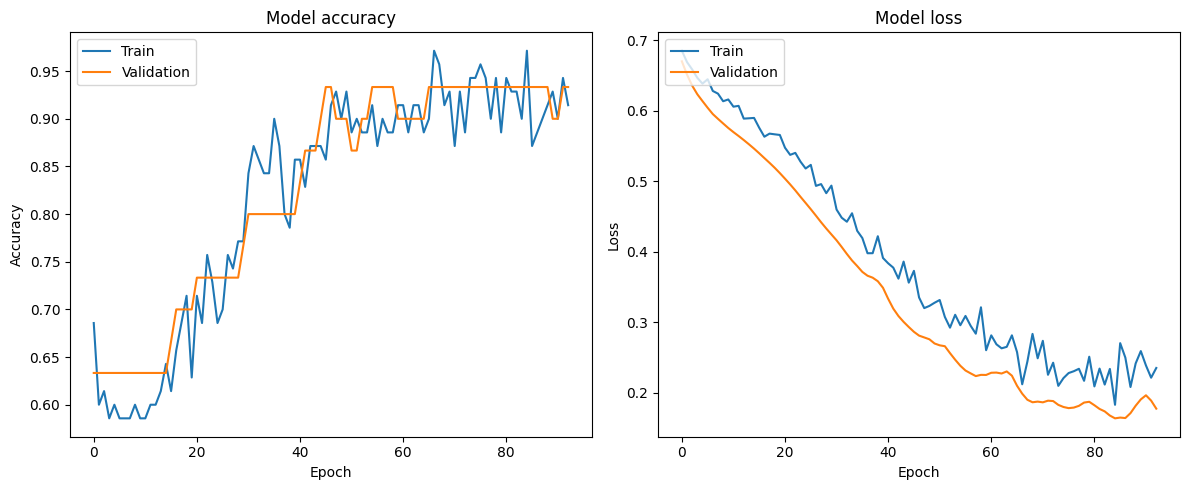

In [162]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


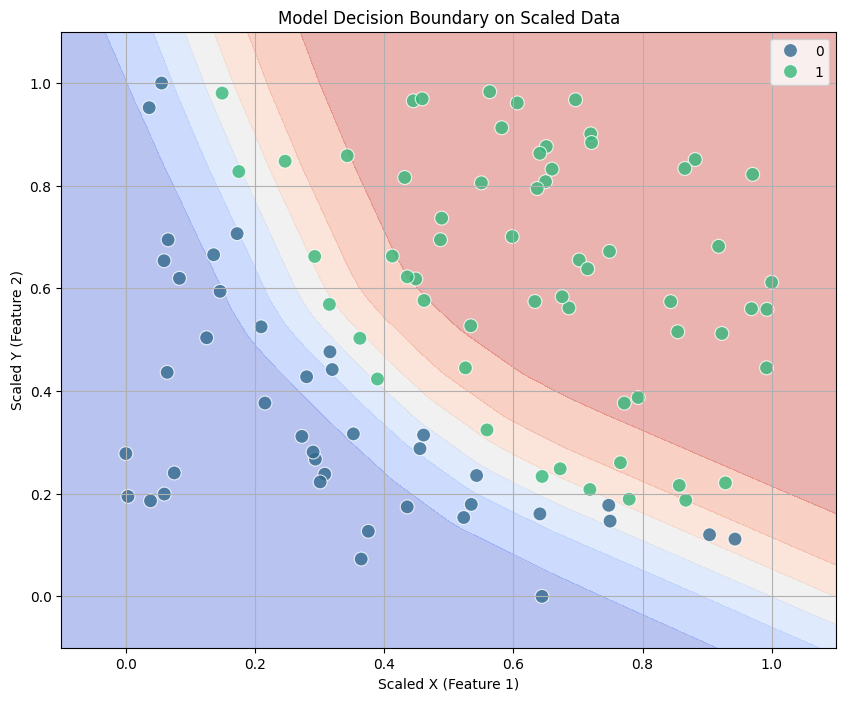

In [163]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get min and max for features to create meshgrid
x_min, x_max = X_scaled[:, 0].min() - 0.1, X_scaled[:, 0].max() + 0.1
y_min, y_max = X_scaled[:, 1].min() - 0.1, X_scaled[:, 1].max() + 0.1

# Create a meshgrid
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict on the meshgrid points
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')

# Plot original data points
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=Y, palette='viridis', legend='full', s=100, alpha=0.8)

plt.title('Model Decision Boundary on Scaled Data')
plt.xlabel('Scaled X (Feature 1)')
plt.ylabel('Scaled Y (Feature 2)')
plt.grid(True)
plt.show()